# TabDM

In [1]:
!wget https://raw.githubusercontent.com/mlgorithm/lak2026-syntheticdata-workshop/refs/heads/main/edu%20dataset/higher_ed_dropout_success.csv

--2026-04-28 09:54:41--  https://raw.githubusercontent.com/mlgorithm/lak2026-syntheticdata-workshop/refs/heads/main/edu%20dataset/higher_ed_dropout_success.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 299727 (293K) [text/plain]
Saving to: ‘higher_ed_dropout_success.csv’

higher_ed_dropout_s 100%[===================>] 292.70K  --.-KB/s    in 0.03s   

2026-04-28 09:54:41 (9.36 MB/s) - ‘higher_ed_dropout_success.csv’ saved [299727/299727]



In [2]:
!pip install "tabdm[eval]"

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tabdm

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

In [4]:
df = pd.read_csv("higher_ed_dropout_success.csv")
df.head()

,row_id,split,marital_status,application_mode,application_order,course,daytime_evening_attendance,previous_qualification,previous_qualification_grade,nacionality,mothers_qualification,fathers_qualification,mothers_occupation,fathers_occupation,admission_grade,displaced,educational_special_needs,debtor,tuition_fees_up_to_date,gender,scholarship_holder,age_at_enrollment,international,curricular_units_1st_sem_credited,curricular_units_1st_sem_enrolled,curricular_units_1st_sem_evaluations,curricular_units_1st_sem_approved,curricular_units_1st_sem_grade,curricular_units_1st_sem_without_evaluations,curricular_units_2nd_sem_credited,curricular_units_2nd_sem_enrolled,curricular_units_2nd_sem_evaluations,curricular_units_2nd_sem_approved,curricular_units_2nd_sem_grade,curricular_units_2nd_sem_without_evaluations,unemployment_rate,inflation_rate,gdp,target
0,higher_ed_dropout_1795,train,1,7,1,8014,0,40,130.0,1,19,1,5,10,130.0,1,0,1,0,0,0,23,0,7,12,12,11,14.0,0,4,10,11,8,14.625000,0,13.9,-0.3,0.79,Dropout
1,higher_ed_dropout_0084,train,2,43,1,9991,0,3,140.0,1,37,19,9,4,140.0,0,0,1,1,0,0,34,0,4,10,25,5,12.2,0,3,9,18,8,12.222222,0,16.2,0.3,-0.92,Dropout
2,higher_ed_dropout_1414,train,1,43,1,8014,0,6,133.1,1,34,34,0,0,100.0,0,0,1,1,0,0,29,0,1,6,9,4,12.0,0,1,6,13,2,10.500000,0,7.6,2.6,0.32,Dropout
3,higher_ed_dropout_0086,train,1,39,1,9003,1,1,130.0,1,12,12,9,9,126.1,0,0,0,1,1,0,24,0,0,6,7,0,0.0,0,0,6,10,0,0.000000,0,12.4,0.5,1.79,Dropout
4,higher_ed_dropout_0450,test,1,39,1,9991,0,1,150.0,1,3,1,3,9,154.0,0,0,0,1,0,0,27,0,0,5,5,0,0.0,0,0,5,6,0,0.000000,0,12.4,0.5,1.79,Dropout


In [5]:
print(df.dtypes.value_counts())
print("\nMissing values:\n", df.isna().sum()[df.isna().sum() > 0])
print("\nDuplicates:", df.duplicated().sum())

int64      29
float64     7
object      3
Name: count, dtype: int64

Missing values:
 Series([], dtype: int64)

Duplicates: 0


In [6]:
df.describe().T[["mean", "std", "min", "50%", "max"]]

,mean,std,min,50%,max
marital_status,1.170085,0.567810,1.00,1.000000,6.000000
application_mode,18.972486,17.469170,1.00,17.000000,53.000000
application_order,1.750875,1.322391,1.00,1.000000,6.000000
course,8846.883942,2078.140256,33.00,9238.000000,9991.000000
daytime_evening_attendance,0.885443,0.318567,0.00,1.000000,1.000000
previous_qualification,4.478739,10.076505,1.00,1.000000,43.000000
previous_qualification_grade,132.532766,13.158680,95.00,133.100000,190.000000
nacionality,1.949975,7.280007,1.00,1.000000,108.000000
mothers_qualification,19.354177,15.604298,1.00,19.000000,43.000000
fathers_qualification,22.175088,15.378747,1.00,19.000000,44.000000


target
Graduate    0.499
Dropout     0.321
Enrolled    0.180
Name: proportion, dtype: float64


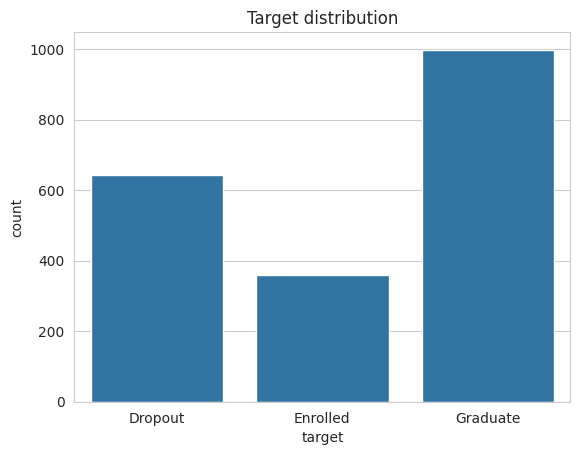

In [7]:
target_col = "target" if "target" in df.columns else None
if target_col:
    print(df[target_col].value_counts(normalize=True).round(3))
    sns.countplot(data=df, x=target_col)
    plt.title("Target distribution"); plt.show()

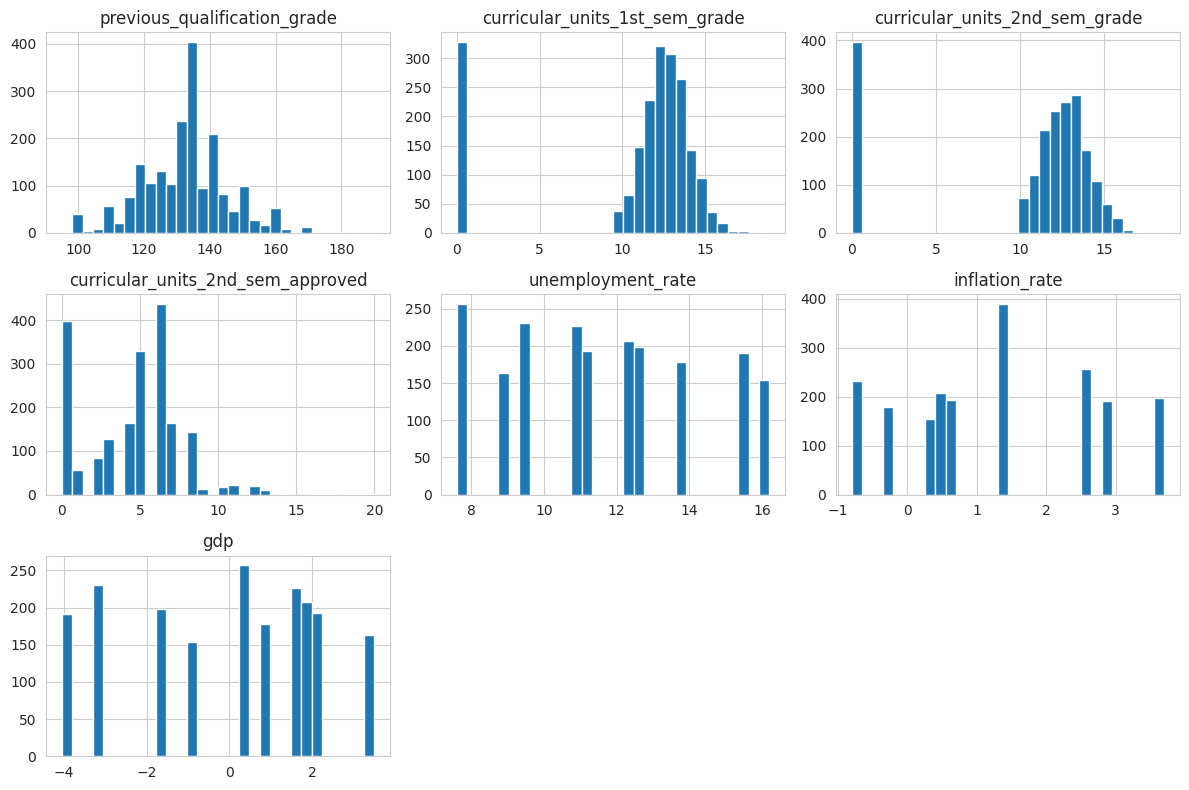

In [8]:
key_cols = [
    "previous_qualification_grade",
    "curricular_units_1st_sem_grade" if "curricular_units_1st_sem_grade" in df.columns else None,
    "curricular_units_2nd_sem_grade",
    "curricular_units_2nd_sem_approved",
    "unemployment_rate", "inflation_rate", "gdp",
]
key_cols = [c for c in key_cols if c and c in df.columns]

df[key_cols].hist(figsize=(12, 8), bins=30)
plt.tight_layout(); plt.show()

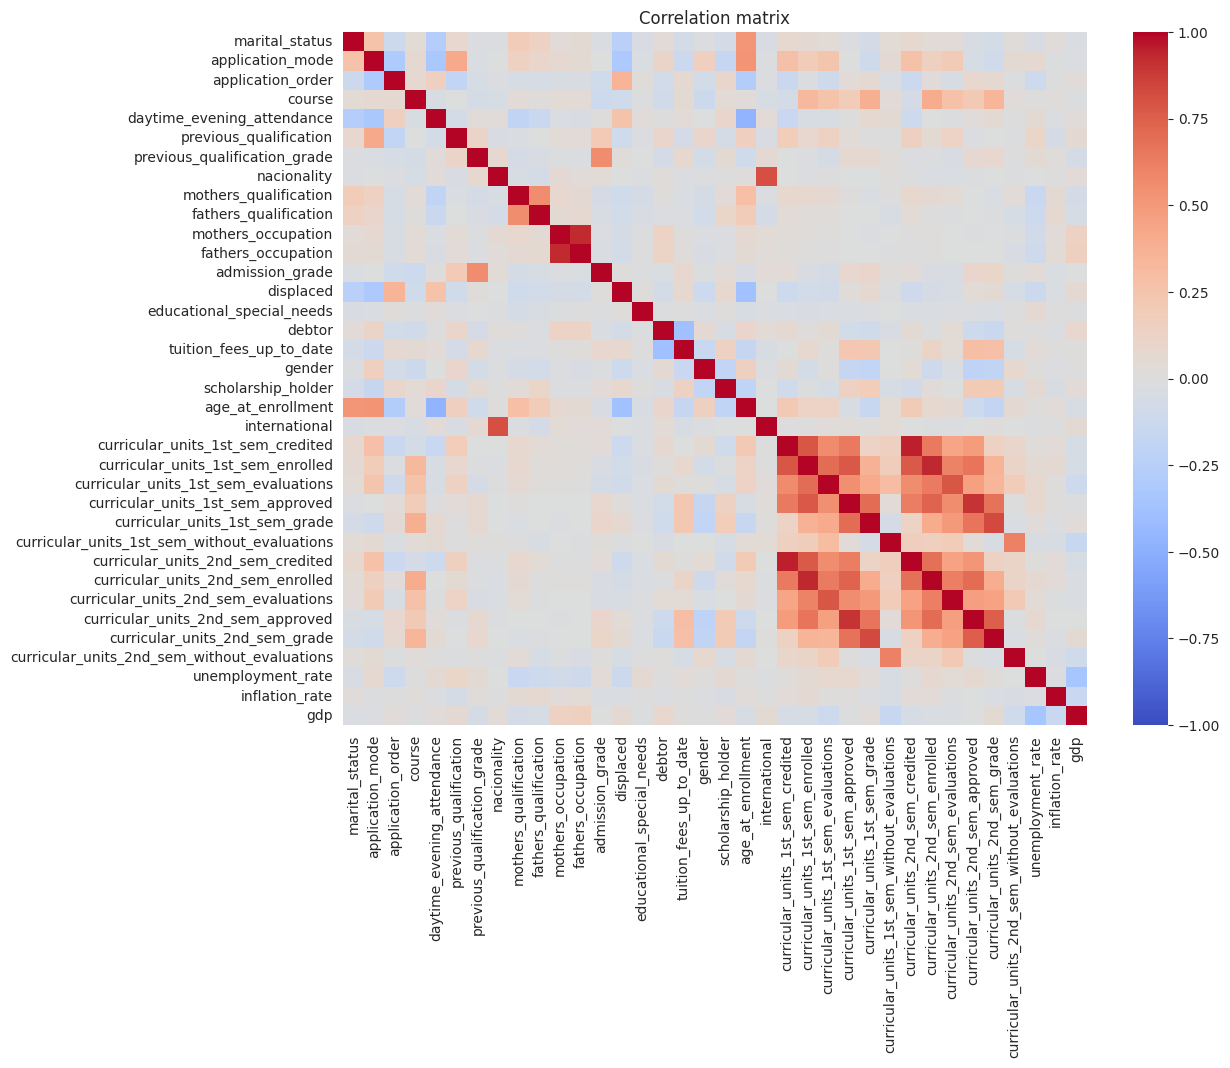

In [9]:
plt.figure(figsize=(12, 9))
corr = df.select_dtypes("number").corr()
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation matrix"); plt.show()

In [10]:
if "curricular_units_2nd_sem_grade" in df.columns:
    top = (corr["curricular_units_2nd_sem_grade"]
           .drop("curricular_units_2nd_sem_grade")
           .abs().sort_values(ascending=False).head(10))
    print("Top correlations with 2nd sem grade:\n", top)

Top correlations with 2nd sem grade:
 curricular_units_1st_sem_grade          0.832016
curricular_units_2nd_sem_approved       0.757447
curricular_units_1st_sem_approved       0.676006
curricular_units_2nd_sem_evaluations    0.456178
curricular_units_2nd_sem_enrolled       0.391626
curricular_units_1st_sem_enrolled       0.355711
course                                  0.351005
curricular_units_1st_sem_evaluations    0.349316
tuition_fees_up_to_date                 0.277667
scholarship_holder                      0.199131
Name: curricular_units_2nd_sem_grade, dtype: float64


In [11]:
for c in ["marital_status", "daytime_evening_attendance", "course"]:
    if c in df.columns:
        print(f"\n{c}:\n", df[c].value_counts().head(10))


marital_status:
 marital_status
1    1766
2     185
4      35
5       9
6       2
3       2
Name: count, dtype: int64

daytime_evening_attendance:
 daytime_evening_attendance
1    1770
0     229
Name: count, dtype: int64

course:
 course
9500    359
9147    171
9238    169
9773    151
9085    148
9991    125
9254    119
8014    104
9670    103
9070    102
Name: count, dtype: int64


In [12]:
discrete_cols = [
    c for c in df.columns
    if df[c].dtype.kind in "iu"        # integer types
    or df[c].nunique() <= 20           # few unique values
]

# Continuous = the rest of the numerics
continuous_cols = [
    c for c in df.select_dtypes("number").columns
    if c not in discrete_cols
]

Running e10/t32/s16 ...
Running e10/t64/s16 ...
Running e15/t32/s16 ...
Running e15/t64/s16 ...
Running e25/t32/s16 ...
Running e25/t64/s16 ...


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


Running e50/t64/s16 ...
Running e100/t64/s16 ...
Running e200/t64/s16 ...


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


Running e200/t32/s16 ...


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


Running e200/t128/s16 ...
            label  epochs  timesteps  sample_steps  mean_tvd  mean_ks  \
0     e10/t32/s16      10         32            16     0.600    0.389   
1     e10/t64/s16      10         64            16     0.600    0.385   
2     e15/t32/s16      15         32            16     0.493    0.251   
3     e15/t64/s16      15         64            16     0.594    0.336   
4     e25/t32/s16      25         32            16     0.490    0.150   
5     e25/t64/s16      25         64            16     0.493    0.185   
6     e50/t64/s16      50         64            16     0.413    0.114   
7    e100/t64/s16     100         64            16     0.433    0.103   
8    e200/t64/s16     200         64            16     0.432    0.102   
9    e200/t32/s16     200         32            16     0.473    0.116   
10  e200/t128/s16     200        128            16     0.397    0.096   

    corr_delta  oob_rate  unseen_rate  real_acc  syn_acc  real_f1  syn_f1  \
0        0.114      

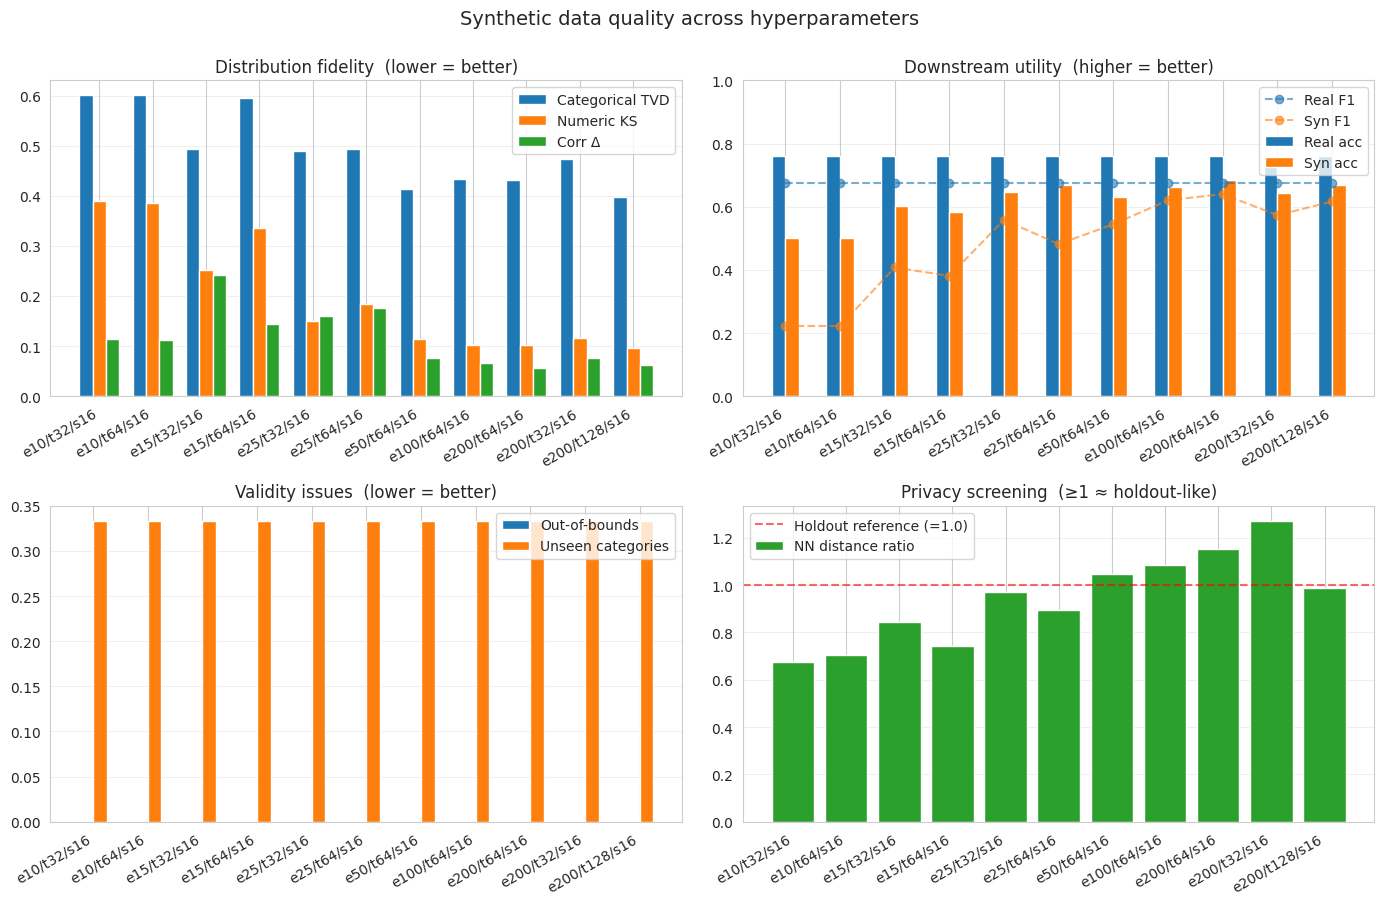

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Define the sweep (edit freely) ----
sweep = [
    {"epochs": 10,  "timesteps": 32,  "sample_steps": 16},
    {"epochs": 10,  "timesteps": 64,  "sample_steps": 16},
    {"epochs": 15,  "timesteps": 32,  "sample_steps": 16},
    {"epochs": 15,  "timesteps": 64,  "sample_steps": 16},
    {"epochs": 25,  "timesteps": 32,  "sample_steps": 16},
    {"epochs": 25,  "timesteps": 64,  "sample_steps": 16},
    {"epochs": 50,  "timesteps": 64,  "sample_steps": 16},
    {"epochs": 100, "timesteps": 64,  "sample_steps": 16},
    {"epochs": 200, "timesteps": 64,  "sample_steps": 16},
    {"epochs": 200,  "timesteps": 32,  "sample_steps": 16},
    {"epochs": 200,  "timesteps": 128, "sample_steps": 16},
]

# ---- Run the sweep, flatten the report ----
rows = []
for p in sweep:
    label = f"e{p['epochs']}/t{p['timesteps']}/s{p['sample_steps']}"
    print(f"Running {label} ...")

    model = tabdm.fit_tabdm(
        df, discrete_columns=discrete_cols, random_state=42, **p
    )
    synthetic = model.generate(len(df), random_state=1)
    report = tabdm.evaluate_synthetic(
        real=df, synthetic=synthetic, target_column="target", random_state=42
    )

    d = report["distribution"]
    v = report["validity"]
    u = report["utility"]
    nn = report["trust"]["privacy_screening"]["nearest_neighbor"]

    rows.append({
        "label":          label,
        **p,
        # distribution (lower = better)
        "mean_tvd":       d["categorical"]["mean_tvd"],
        "mean_ks":        d["numeric"]["mean_ks"],
        "corr_delta":     d["correlation"]["numeric_mean_abs_delta"],
        # validity (lower = better)
        "oob_rate":       v["bounds"]["average_rate"],
        "unseen_rate":    v["unseen_categories"]["average_rate"],
        # utility (higher = better; gap = lower is better)
        "real_acc":       u["baseline_real_accuracy"],
        "syn_acc":        u["synthetic_accuracy"],
        "real_f1":        u["baseline_real_macro_f1"],
        "syn_f1":         u["synthetic_macro_f1"],
        # privacy (~1 = holdout-like, <1 = closer than holdout)
        "nn_dist_ratio":  nn["distance_ratio_to_holdout"],
        "below_5pct":     nn["below_holdout_5th_percentile_rate"],
    })

res = pd.DataFrame(rows)
print(res.round(3))

# ---- Aggregate plot ----
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
x = np.arange(len(res))
w = 0.25

# (1) Distribution fidelity — lower is better
ax = axes[0, 0]
ax.bar(x - w, res["mean_tvd"],   w, label="Categorical TVD")
ax.bar(x,     res["mean_ks"],    w, label="Numeric KS")
ax.bar(x + w, res["corr_delta"], w, label="Corr Δ")
ax.set_title("Distribution fidelity  (lower = better)")
ax.set_xticks(x); ax.set_xticklabels(res["label"], rotation=30, ha="right")
ax.legend(); ax.grid(axis="y", alpha=0.3)

# (2) Utility — real vs synthetic
ax = axes[0, 1]
ax.bar(x - w/2, res["real_acc"], w, label="Real acc", color="C0")
ax.bar(x + w/2, res["syn_acc"],  w, label="Syn acc",  color="C1")
ax.plot(x, res["real_f1"], "o--", color="C0", alpha=0.6, label="Real F1")
ax.plot(x, res["syn_f1"],  "o--", color="C1", alpha=0.6, label="Syn F1")
ax.set_title("Downstream utility  (higher = better)")
ax.set_ylim(0, 1)
ax.set_xticks(x); ax.set_xticklabels(res["label"], rotation=30, ha="right")
ax.legend(); ax.grid(axis="y", alpha=0.3)

# (3) Validity — lower is better
ax = axes[1, 0]
ax.bar(x - w/2, res["oob_rate"],    w, label="Out-of-bounds")
ax.bar(x + w/2, res["unseen_rate"], w, label="Unseen categories")
ax.set_title("Validity issues  (lower = better)")
ax.set_xticks(x); ax.set_xticklabels(res["label"], rotation=30, ha="right")
ax.legend(); ax.grid(axis="y", alpha=0.3)

# (4) Privacy — NN distance ratio vs holdout reference
ax = axes[1, 1]
ax.bar(x, res["nn_dist_ratio"], color="C2", label="NN distance ratio")
ax.axhline(1.0, color="red", ls="--", alpha=0.6, label="Holdout reference (=1.0)")
ax.set_title("Privacy screening  (≥1 ≈ holdout-like)")
ax.set_xticks(x); ax.set_xticklabels(res["label"], rotation=30, ha="right")
ax.legend(); ax.grid(axis="y", alpha=0.3)

plt.suptitle("Synthetic data quality across hyperparameters", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()